# Data Exploration


In [69]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [70]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from src.common import mpl_apply

In [71]:
df = pd.read_csv("../data/climate-daily-complete.csv")
df.head()

,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,LOCAL_DATE_dt,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,MEAN_TEMPERATURE,MIN_TEMPERATURE,MAX_TEMPERATURE,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,COOLING_DEGREE_DAYS,HEATING_DEGREE_DAYS
0,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605,8403605.2000.3.1,2000-03-01 00:00:00,2000-03-01,NL,2000,3,1,1.600000,0.600000,2.60000,0.900000,1.000000,0.000000,0.761606,0.000000,16.400000
1,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605,8403605.2000.3.2,2000-03-02 00:00:00,2000-03-02,NL,2000,3,2,3.800000,0.100000,7.50000,4.700000,4.750913,0.000000,4.262214,0.000000,14.200000
2,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605,8403605.2000.3.3,2000-03-03 00:00:00,2000-03-03,NL,2000,3,3,6.980000,1.200000,6.86000,2.960000,16.660000,0.000000,10.800000,0.000000,11.020000
3,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605,8403605.2000.3.4,2000-03-04 00:00:00,2000-03-04,NL,2000,3,4,5.739584,1.841009,9.61894,3.400667,2.799939,0.468775,6.029309,0.142983,12.403399
4,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605,8403605.2000.3.5,2000-03-05 00:00:00,2000-03-05,NL,2000,3,5,5.739584,1.841009,9.61894,3.400667,2.799939,0.468775,6.029309,0.142983,12.403399


In [72]:
df = df.sort_values('LOCAL_DATE_dt')

In [73]:
df.STATION_NAME.unique()

array(['LOGY BAY', 'SIGNAL HILL', "ST JOHN'S WEST CDA CS",
       'ST JOHNS WEST CLIMATE'], dtype=object)

In [74]:
mpl_apply()

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Create datetime from year/month/day
df['date'] = pd.to_datetime(df[['LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY']].rename(columns={
    'LOCAL_YEAR': 'year',
    'LOCAL_MONTH': 'month',
    'LOCAL_DAY': 'day'
}))

# Sort by date
df = df.sort_values('date')

In [76]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'LOCAL_DATE_dt', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH',
       'LOCAL_DAY', 'MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE',
       'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND',
       'COOLING_DEGREE_DAYS', 'HEATING_DEGREE_DAYS', 'date'],
      dtype='object')

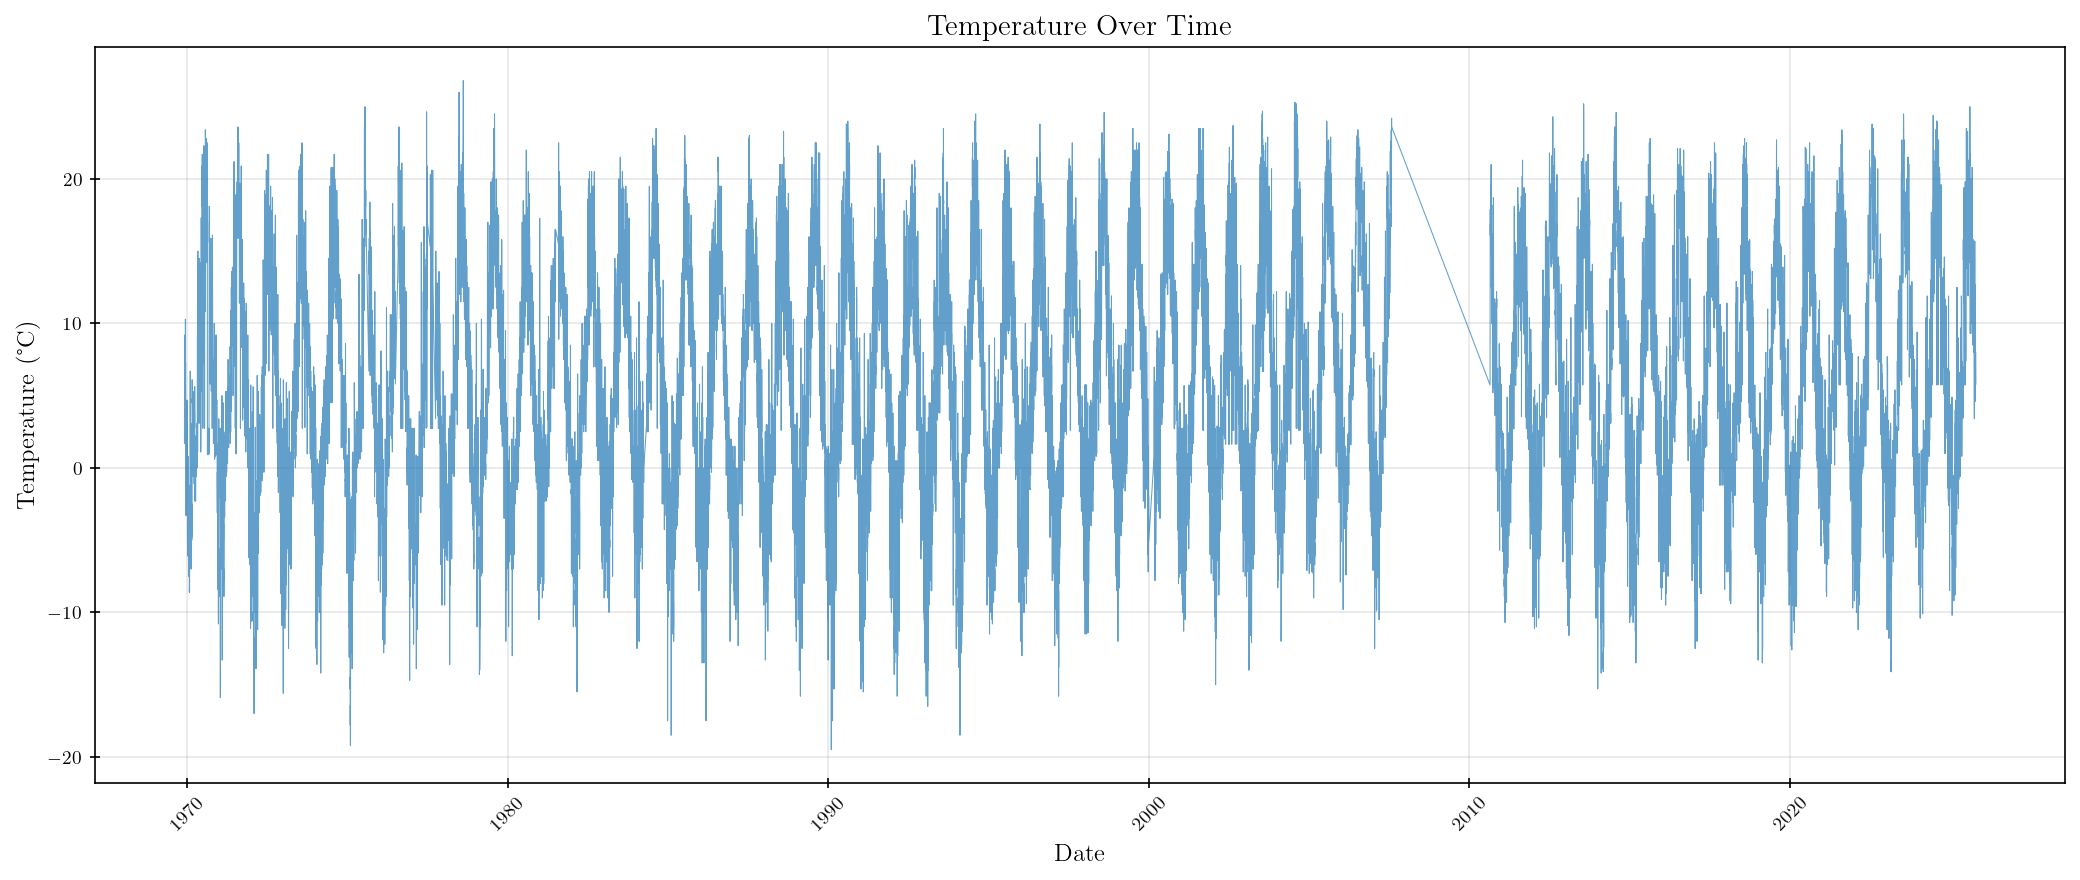

In [77]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['MEAN_TEMPERATURE'], linewidth=0.5, alpha=0.7)
plt.title('Temperature Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

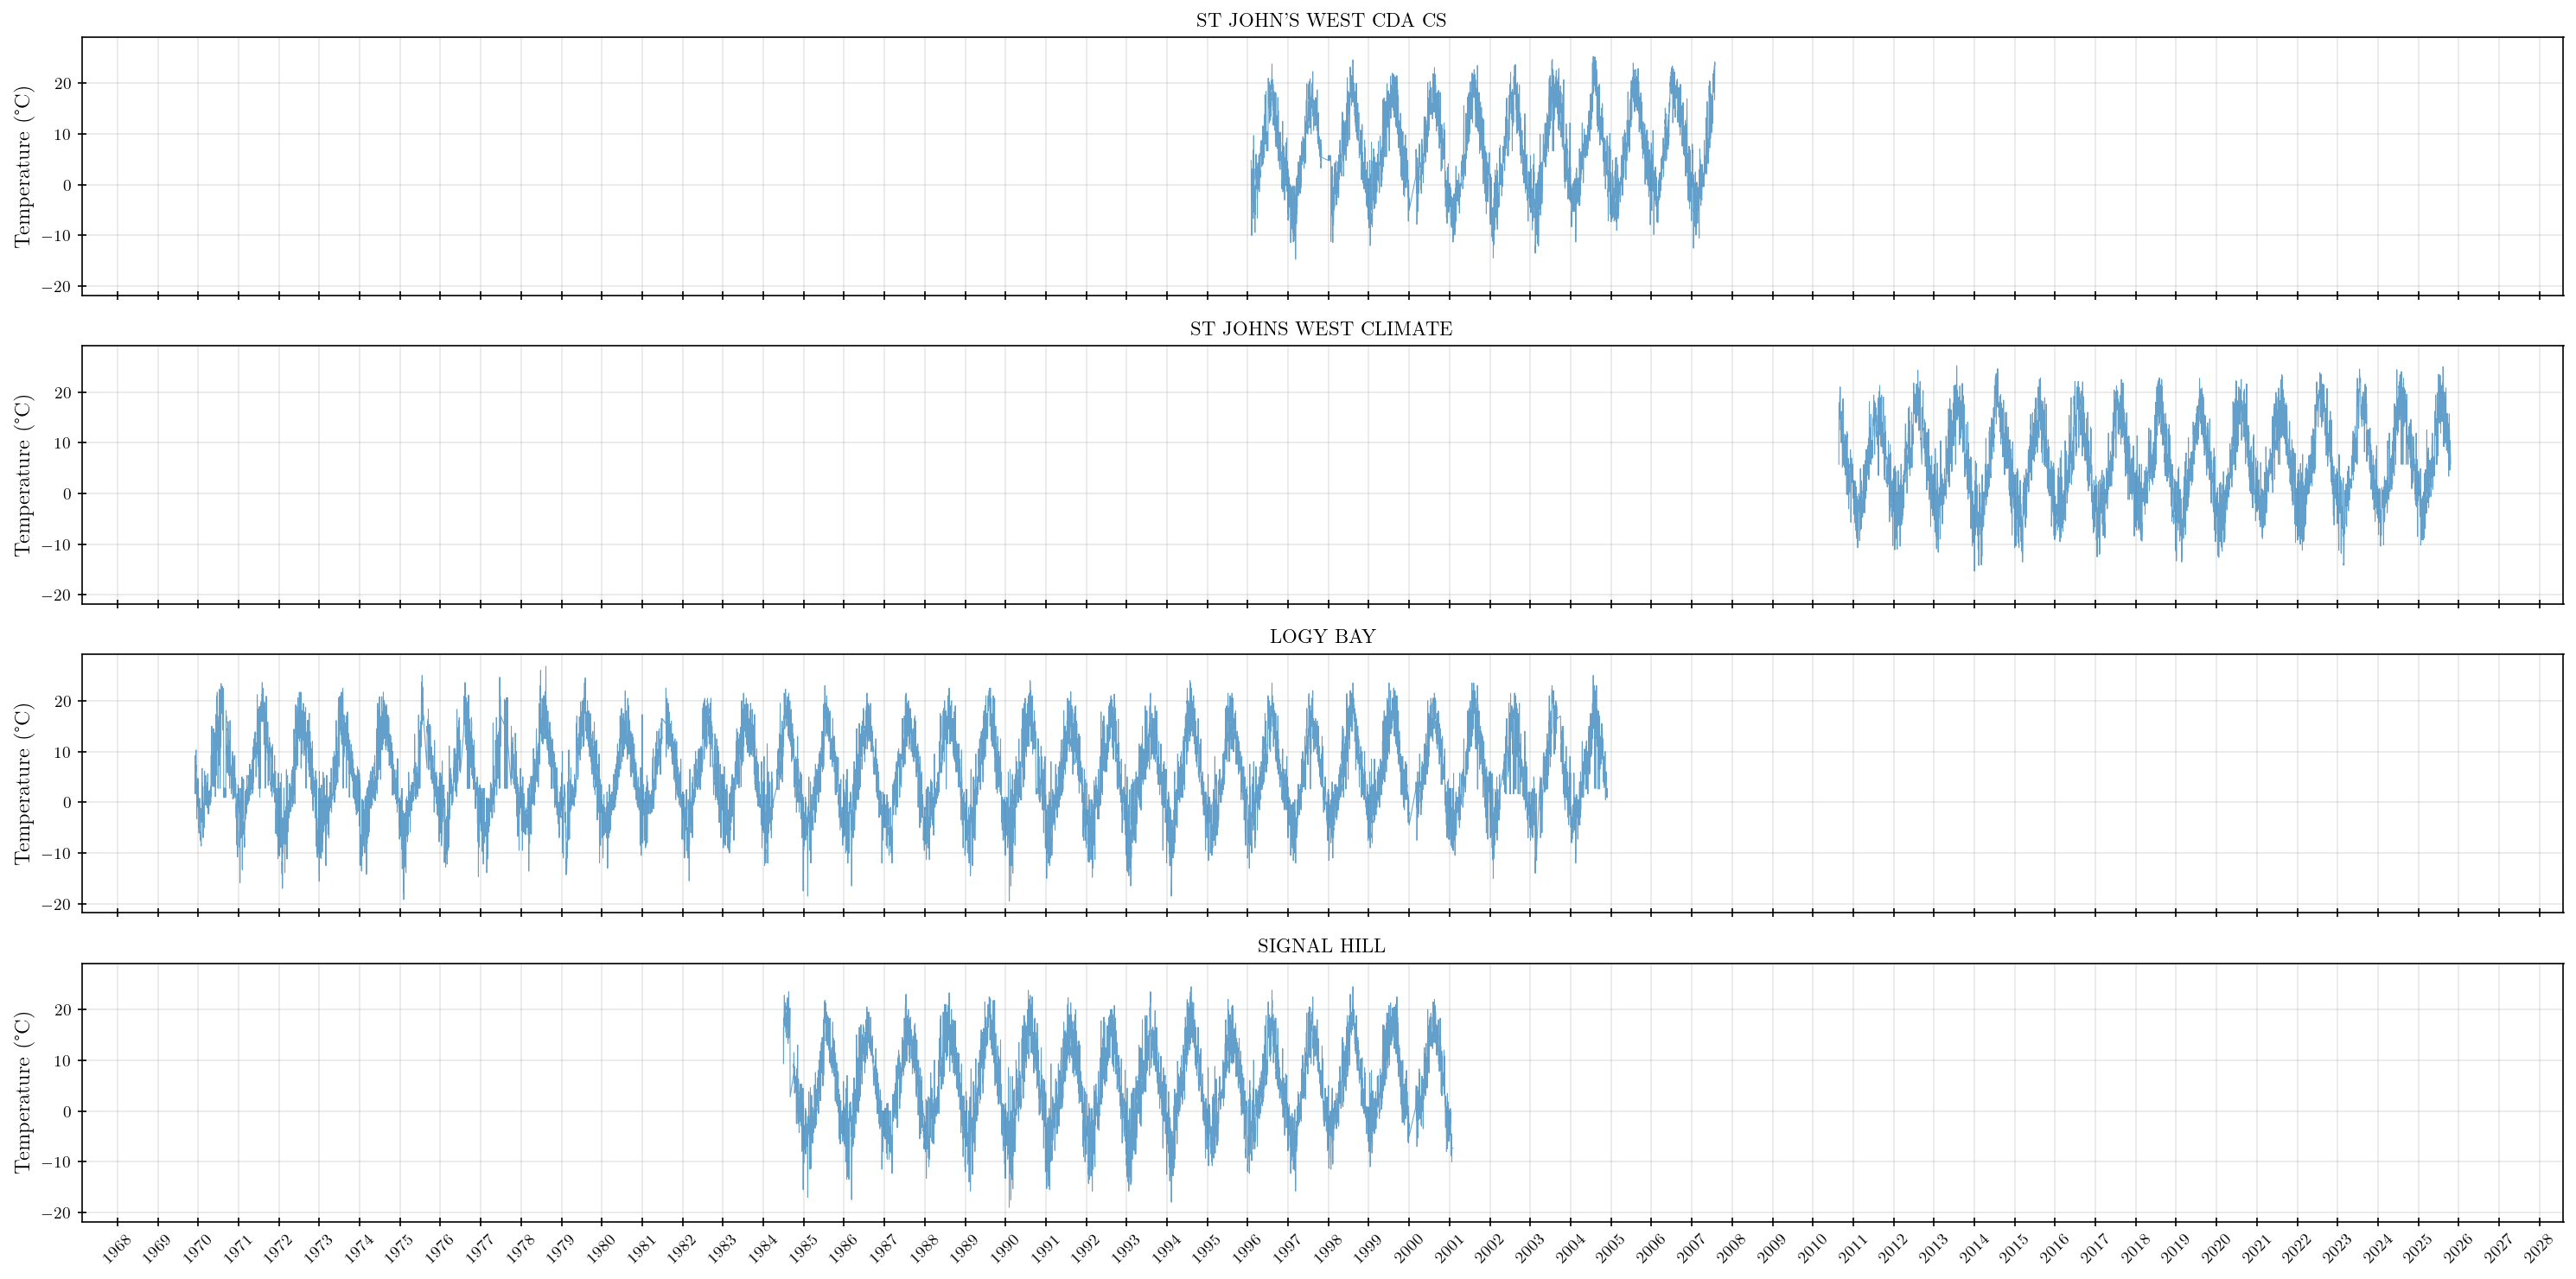

In [92]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(20, 10), sharey=True, sharex=True)
stations = ["ST JOHN'S WEST CDA CS",
            'ST JOHNS WEST CLIMATE',
            'LOGY BAY',
            'SIGNAL HILL']

for ax, station in zip(axes, stations):
    station_data = df[df['STATION_NAME'] == station]
    ax.plot(station_data['date'],
            station_data['MEAN_TEMPERATURE'], linewidth=0.5, alpha=0.7)
    # ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title(station)

    ax.xaxis.set_major_locator(mdates.YearLocator(1))  # Every 1 year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/mean_temp_over_time_by_station.pdf")

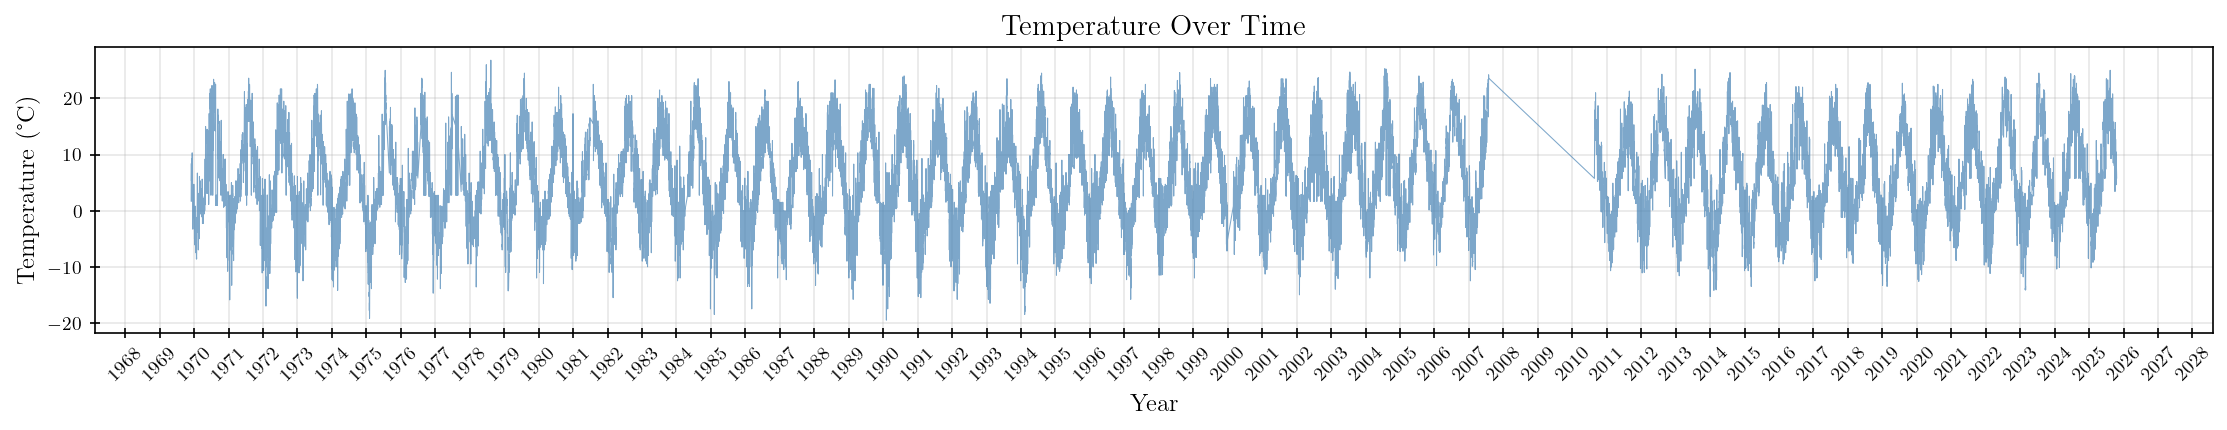

In [79]:
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(df['date'], df['MEAN_TEMPERATURE'],
        linewidth=0.5, alpha=0.7, color='steelblue')

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/mean_temp_over_time.pdf")

In [80]:
# Import DTR function
from src.dtr_calc import calculate_dtr

## DTR Analysis

In [81]:
# Calculate dtr time series data
df["DTR"] = calculate_dtr(t_min=df["MIN_TEMPERATURE"],
                          t_max=df["MAX_TEMPERATURE"])

ValueError: t_min must be <= t_max for all entries

Some samples have `MAX_TEMPERATURE` less than `MIN_TEMPERATURE`.

In [82]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'LOCAL_DATE_dt', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH',
       'LOCAL_DAY', 'MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE',
       'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND',
       'COOLING_DEGREE_DAYS', 'HEATING_DEGREE_DAYS', 'date'],
      dtype='object')

In [83]:
# Find invalid rows
invalid = df[df["MAX_TEMPERATURE"] < df["MIN_TEMPERATURE"]]
print(invalid[["date", "MIN_TEMPERATURE", "MAX_TEMPERATURE", "STATION_NAME"]])

            date  MIN_TEMPERATURE  MAX_TEMPERATURE           STATION_NAME
11695 1970-03-22             4.70             2.20               LOGY BAY
11701 1970-03-28             8.60             3.64               LOGY BAY
11812 1970-07-17            17.80             4.32               LOGY BAY
11844 1970-08-18            16.70             6.20               LOGY BAY
12239 1971-09-17            16.70            15.60               LOGY BAY
12347 1972-01-03             8.94             6.70               LOGY BAY
12402 1972-02-27             1.54            -1.70               LOGY BAY
12708 1972-12-29            -4.14            -6.70               LOGY BAY
12851 1973-05-21             7.42             4.40               LOGY BAY
13077 1974-01-02             7.48             6.70               LOGY BAY
13081 1974-01-06            -4.90            -7.20               LOGY BAY
13150 1974-03-16             4.08             2.80               LOGY BAY
14059 1976-11-11             4.08     

In [84]:
print(f"Invalid samples: {len(invalid)}")
print(f"Total number of samples: {df.shape[0]}")

Invalid samples: 46
Total number of samples: 28020


Because there are $\frac{46}{28020}$, less than 0.164% of the data, deleting should not significantly affect the results of our DTR calculation.

In [85]:
# Remove rows where MIN > MAX
ds = df[df["MAX_TEMPERATURE"] >= df["MIN_TEMPERATURE"]].copy()

# Now calculate DTR
ds["DTR"] = calculate_dtr(t_min=ds["MIN_TEMPERATURE"],
                          t_max=ds["MAX_TEMPERATURE"])

#### All DTR samples

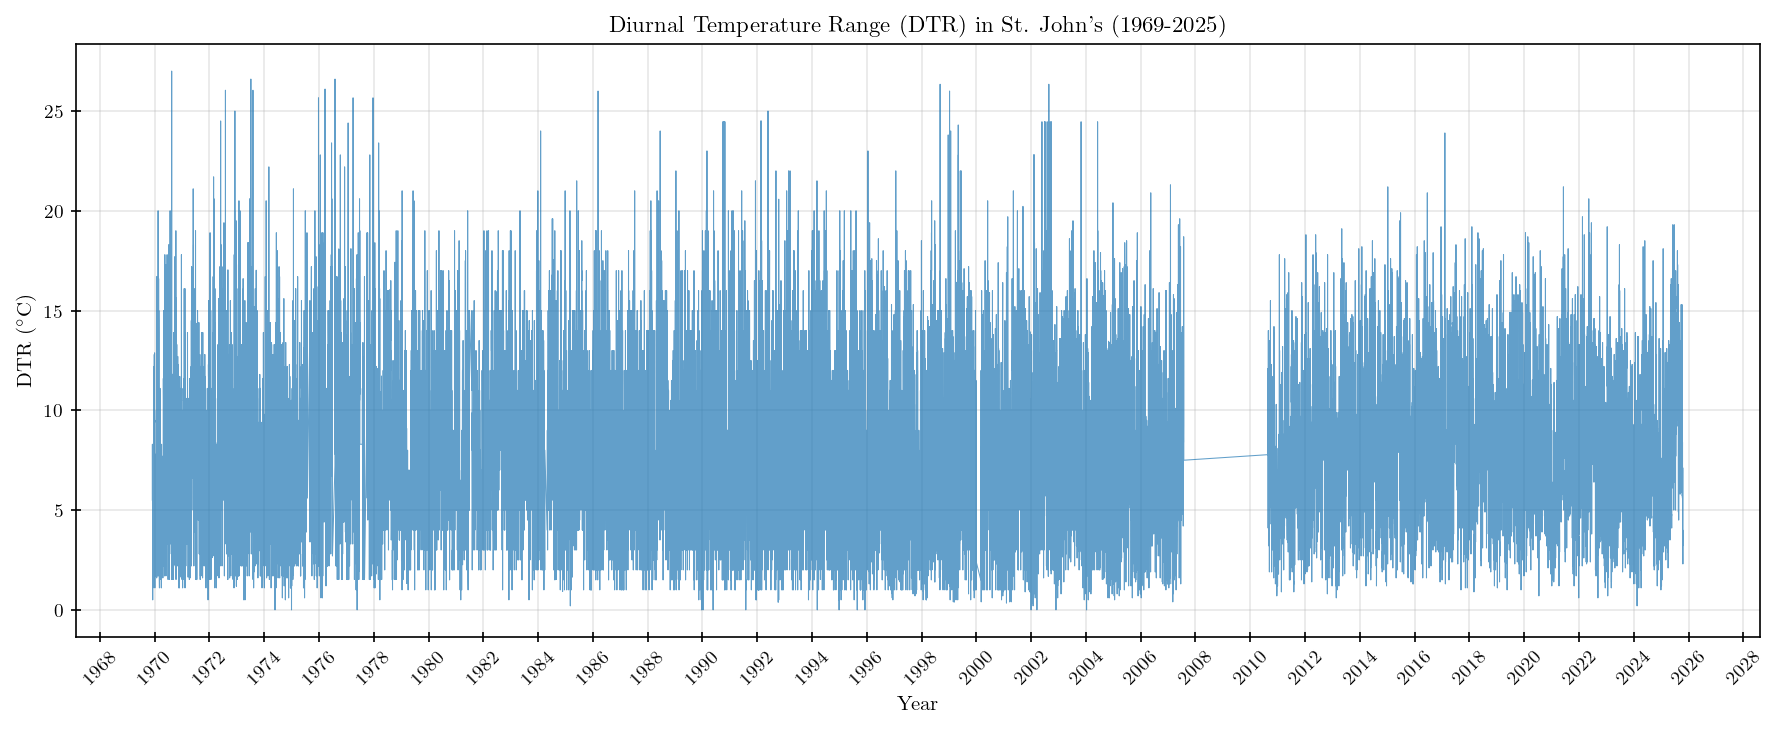

In [86]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))
plt.plot(ds["date"], ds["DTR"], linewidth=0.5, alpha=0.7)
plt.title('Diurnal Temperature Range (DTR) in St. John\'s (1969-2025)')
plt.xlabel('Year')
plt.ylabel('DTR ($^{\\circ}$C)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/dtr_over_time.pdf", dpi=300)
plt.show()

Plotting individual DTR values for each day, provides visual noise. I will try to see if I can find any trends/patterns in the yearly and/or monthly plot.

#### Yearly Mean DTR

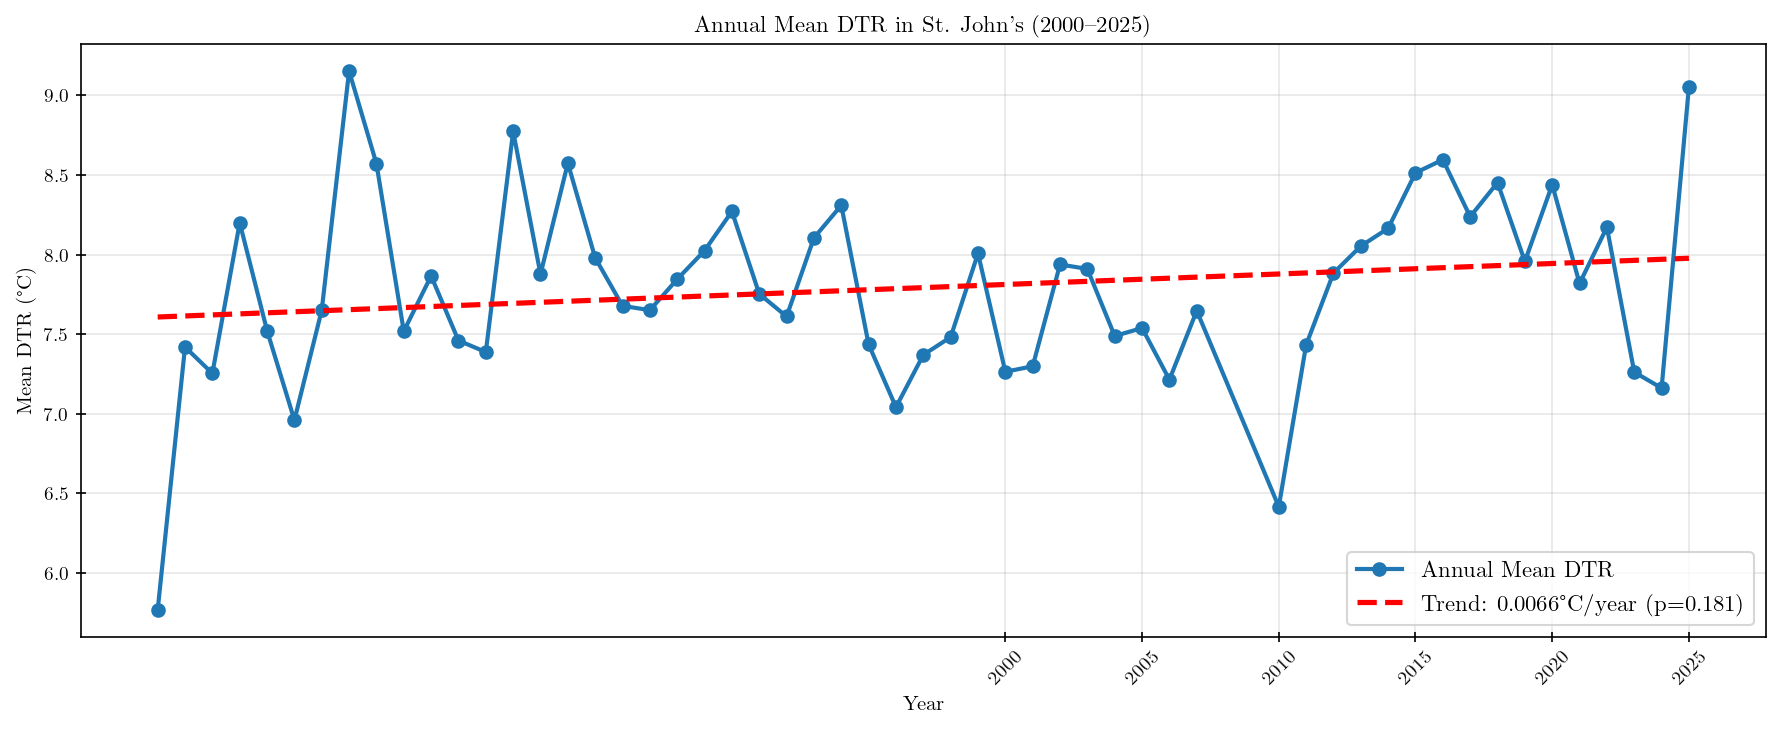

In [87]:
# Create plot
plt.figure(figsize=(12, 5))
plt.plot(annual_dtr.index, annual_dtr.values, marker='o', linewidth=2, 
         markersize=6, label='Annual Mean DTR')
plt.plot(annual_dtr.index, trend_line, 'r--', linewidth=2.5, 
         label=f'Trend: {slope:.4f}°C/year (p={p_value:.3f})')

plt.title('Annual Mean DTR in St. John\'s (2000–2025)')
plt.xlabel('Year')
plt.ylabel('Mean DTR (°C)')
plt.legend(fontsize=11)
plt.xticks(range(2000, 2026, 5), rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/annual_dtr_trend.pdf", dpi=300)
plt.show()

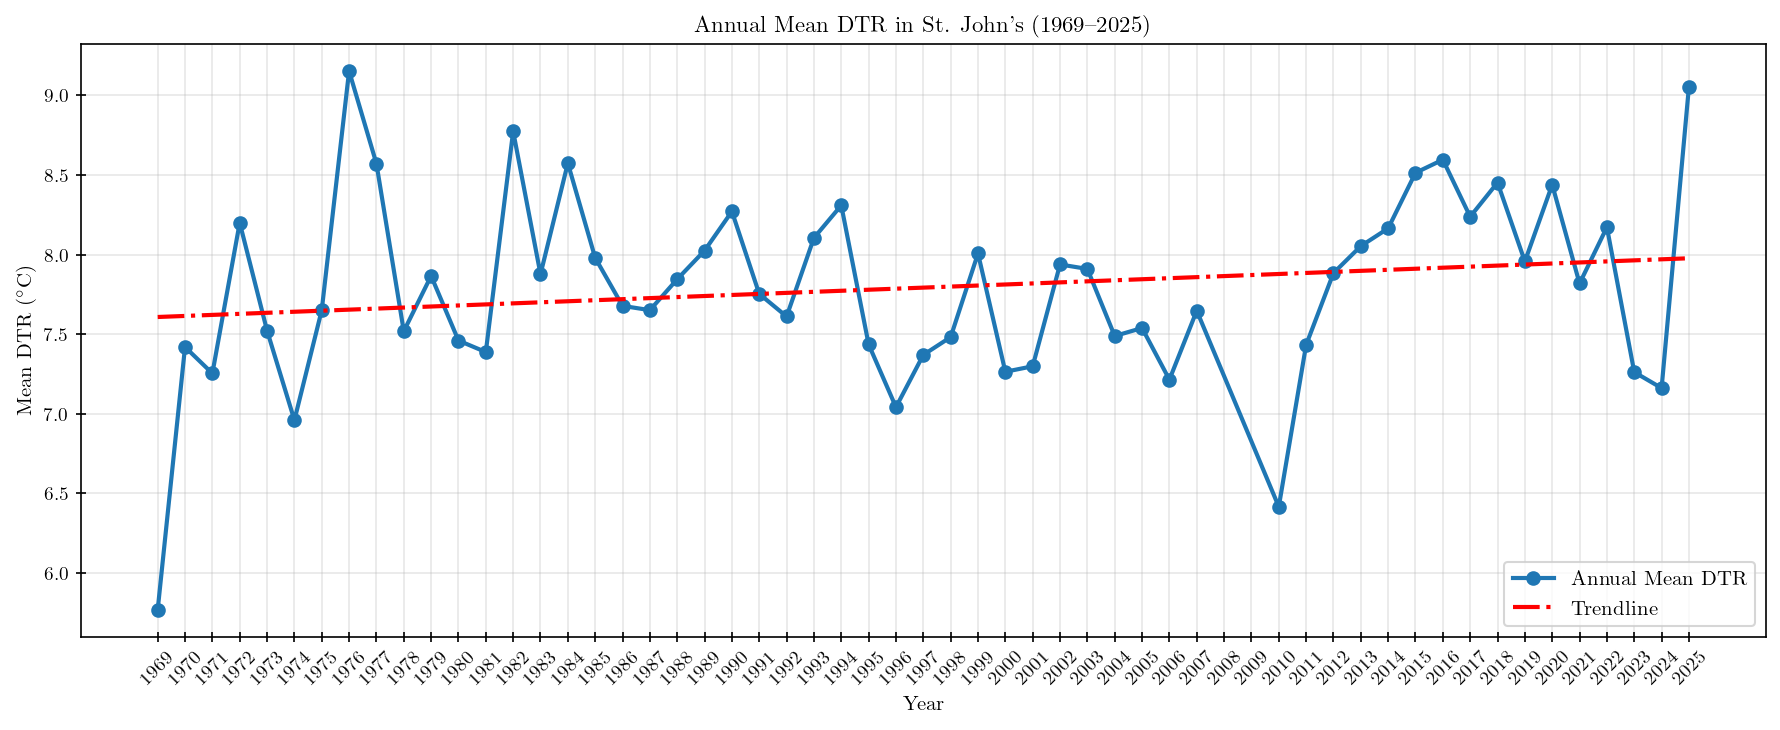

In [88]:
# Calculate annual mean DTR
annual_dtr = ds.groupby(ds['date'].dt.year)['DTR'].mean()

# Fit linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_dtr.index, annual_dtr.values
)

# Generate trendline
trend_line = slope * annual_dtr.index + intercept

plt.figure(figsize=(12, 5))
plt.plot(annual_dtr.index, annual_dtr.values,
         marker='o', linewidth=2, markersize=6, label='Annual Mean DTR')
plt.plot(annual_dtr.index, trend_line, 'r-.', linewidth=2, 
         label=f'Trendline')
plt.title('Annual Mean DTR in St. John\'s (1969–2025)')
plt.xlabel('Year')
plt.ylabel('Mean DTR ($^{\\circ}$C)')

plt.xticks(range(int(annual_dtr.index.min()), int(annual_dtr.index.max()) + 1, 1),
           rotation=45)

plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../plots/annual_dtr_trend.pdf", dpi=300)
plt.show()

In [89]:
# Print statistics
print(f"Slope: {slope:.4f} °C/year")
print(f"Intercept: {intercept:.2f} °C")
print(f"p-value: {p_value:.3f}")
print(f"R²: {r_value**2:.3f}")
print(f"Significant at α=0.05? {'Yes' if p_value < 0.05 else 'No'}")

Slope: 0.0066 °C/year
Intercept: -5.37 °C
p-value: 0.181
R²: 0.034
Significant at α=0.05? No


#### DTR Distribution by Month

<Figure size 1800x750 with 0 Axes>

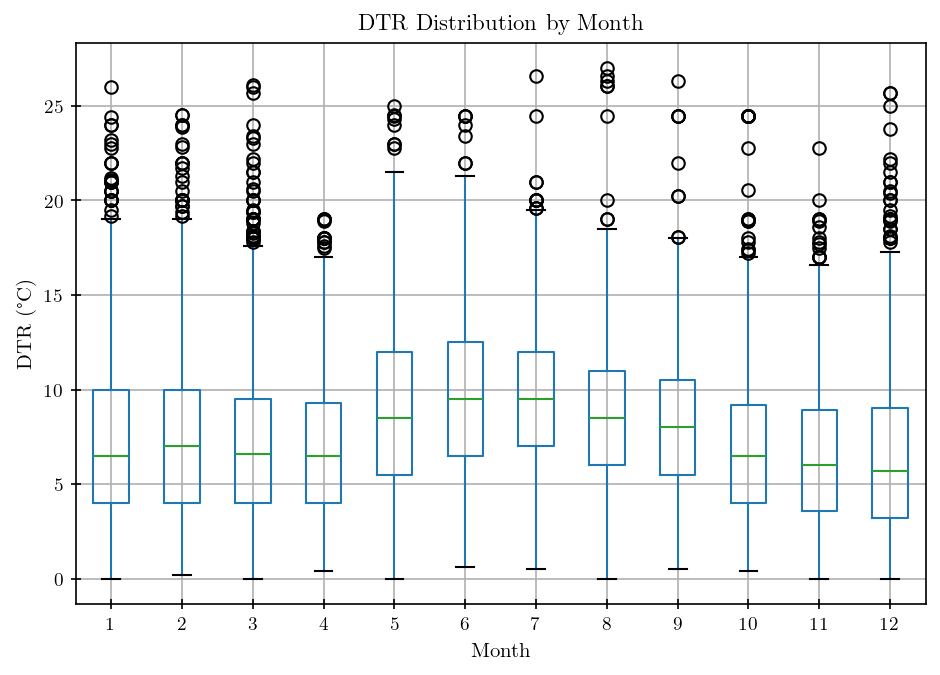

In [90]:
ds['month'] = ds['date'].dt.month
plt.figure(figsize=(12, 5))
ds.boxplot(column='DTR', by='month')
plt.title('DTR Distribution by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('DTR (°C)')
plt.tight_layout()
plt.savefig("../plots/dtr_seasonal.pdf", dpi=300)
plt.show()

#### Mean DTR by Month

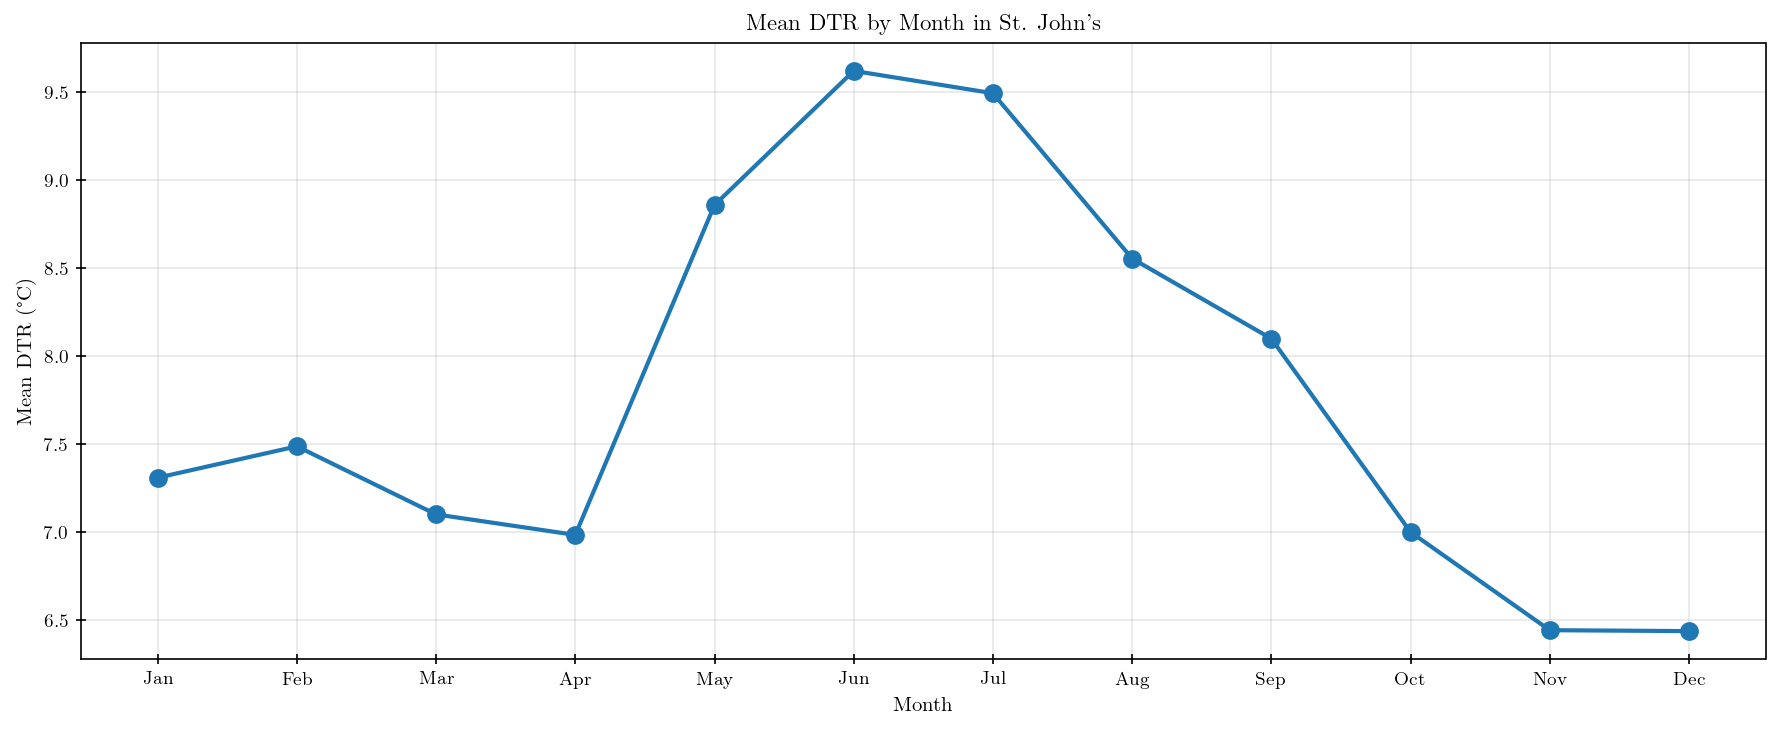

date
1     7.308964
2     7.487203
3     7.100552
4     6.983987
5     8.858127
6     9.620225
7     9.493092
8     8.554145
9     8.098998
10    7.000201
11    6.442716
12    6.437558
Name: DTR, dtype: float64


In [91]:
# Calculate mean DTR for each month across all years
monthly_dtr = ds.groupby(ds['date'].dt.month)['DTR'].mean()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_dtr.index, monthly_dtr.values,
         marker='o', linewidth=2, markersize=8)
plt.title('Mean DTR by Month in St. John\'s')
plt.xlabel('Month')
plt.ylabel('Mean DTR (°C)')

# Set x-axis to month names
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), months)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/dtr_by_month.pdf", dpi=300)
plt.show()

# Print values
print(monthly_dtr)

* Winter (Dec–Mar): Suppressed DTR (6.3–7.5°C) — ocean moderates day-night swings
* Spring (Apr–May): Transition (7.0–8.8°C) — increasing solar angle, clearer skies
* Summer (Jun–Aug): Peak DTR (9.5–9.6°C) — maximum contrast, strong daytime heating, clear nights
* Fall (Sep–Nov): Decline (6.4–8.1°C) — returning cloud cover, weakening solar angle